# **Project Name**    -  Amazon Prime EDA Project 



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
#####  Team Member 1     - Aryan Sharma

This project performs Exploratory Data Analysis (EDA) on the Netflix Titles dataset to
find interesting patterns and insights about movies and shows available on the platform.

The dataset has two files:
- titles.csv (9,871 rows, 15 columns) — movie/show metadata like title, genres, IMDb score,
  release year, runtime, production countries, etc.
- credits.csv (1,24,235 rows, 5 columns) — cast and crew information.

EDA is done in 3 phases following the UBM rule:
- U (Univariate Analysis): Distribution of individual variables
- B (Bivariate Analysis): Relationship between two variables
- M (Multivariate Analysis): Relationship between multiple variables

Key Findings:
- Most movies score between 5–7 on IMDb
- Drama is the most common genre by a large margin
- TMDB popularity is weakly correlated with IMDb quality
- Older movies tend to have higher average ratings
- Content production grew exponentially after 2000

# **GitHub Link -**

[https://github.com/Aryan001521/Amazon-Prime-TV-and-Shows-]

# **Problem Statement**


With thousands of movies on streaming platforms, it is important to understand
what kind of content exists, how it is rated, and what patterns emerge from the data.
This EDA project analyzes the Netflix titles dataset to uncover key trends in genres,
ratings, runtime, popularity, and content growth over time.



#### **Define Your Business Objective?**

The business objective is to help streaming platforms make data-driven decisions
about content acquisition, user recommendations, and homepage curation by
understanding which genres, eras, and types of movies perform best in terms of
quality and popularity.With thousands of movies on streaming platforms, it is important to understand what
kind of content exists, how it is rated, and what patterns emerge from the data.
This EDA project aims to analyze the Netflix titles dataset to uncover key trends in
genres, ratings, runtime, popularity, and content growth over time.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [62]:
import pandas as pd                  # Data manipulation
import numpy as np                   # Numerical operations
import matplotlib.pyplot as plt      # Charts
import seaborn as sns                # Statistical charts
import ast                           # Convert genre string to list
import warnings
import os 
warnings.filterwarnings('ignore')
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ All Libraries Imported Successfully!')

/kaggle/input/datasets/aryansharmabf/title-csv/titles.csv
/kaggle/input/datasets/aryansharmabf/credit/credits.csv
✅ All Libraries Imported Successfully!


### Dataset Loading

In [63]:
credit = pd.read_csv('/kaggle/input/datasets/aryansharmabf/credit/credits.csv')   # Movie/show metadata
title = pd.read_csv('/kaggle/input/datasets/aryansharmabf/title-csv/titles.csv')  # Cast & crew info

print(' Datasets Loaded')
print(f'   titles.csv  → Shape: {title.shape}')
print(f'   credits.csv → Shape: {credit.shape}')

 Datasets Loaded
   titles.csv  → Shape: (9871, 15)
   credits.csv → Shape: (124235, 5)


### Dataset First View

In [64]:
# Dataset First Look
print('─── titles.csv — First 5 Rows ───')
display(title.head())

print('\n─── credits.csv — First 5 Rows ───')
display(credit.head())

─── titles.csv — First 5 Rows ───


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6



─── credits.csv — First 5 Rows ───


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [65]:
# Dataset Rows & Columns count
print('─── titles.csv ───')
print(f'   Rows    : {title.shape[0]}')
print(f'   Columns : {title.shape[1]}')

print('\n─── credits.csv ───')
print(f'   Rows    : {credit.shape[0]}')
print(f'   Columns : {credit.shape[1]}')

─── titles.csv ───
   Rows    : 9871
   Columns : 15

─── credits.csv ───
   Rows    : 124235
   Columns : 5


### Dataset Information

In [66]:
# Dataset Info
print('─── titles.csv — Info ───')
title.info()

print('\n─── credits.csv — Info ───')
credit.info()

─── titles.csv — Info ───
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64


#### Duplicate Values

In [67]:
# Dataset Duplicate Value Count
print(f"titles.csv -> duplicates :{title.duplicated().sum()} ")
print(f'credits.csv -> duplicates :{credit.duplicated().sum()}')

titles.csv -> duplicates :3 
credits.csv -> duplicates :56


#### Missing Values/Null Values

In [68]:
# Missing Values/Null Values Count
print('─── titles.csv — Missing Values ───')
miss = title.isnull().sum()
miss_pct = (miss / len(title) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
display(miss_df[miss_df['Missing Count'] > 0 ].sort_values("Missing Count",ascending = False))

print('\n─── credits.csv — Missing Values ───')
cmiss = credit.isnull().sum()
display(pd.DataFrame({'Missing Count': cmiss,
                      'Missing %': (cmiss / len(credit) * 100).round(2)}))


─── titles.csv — Missing Values ───


,Missing Count,Missing %
seasons,8514,86.25
age_certification,6487,65.72
tmdb_score,2082,21.09
imdb_votes,1031,10.44
imdb_score,1021,10.34
imdb_id,667,6.76
tmdb_popularity,547,5.54
description,119,1.21



─── credits.csv — Missing Values ───


,Missing Count,Missing %
person_id,0,0.00
id,0,0.00
name,0,0.00
character,16287,13.11
role,0,0.00


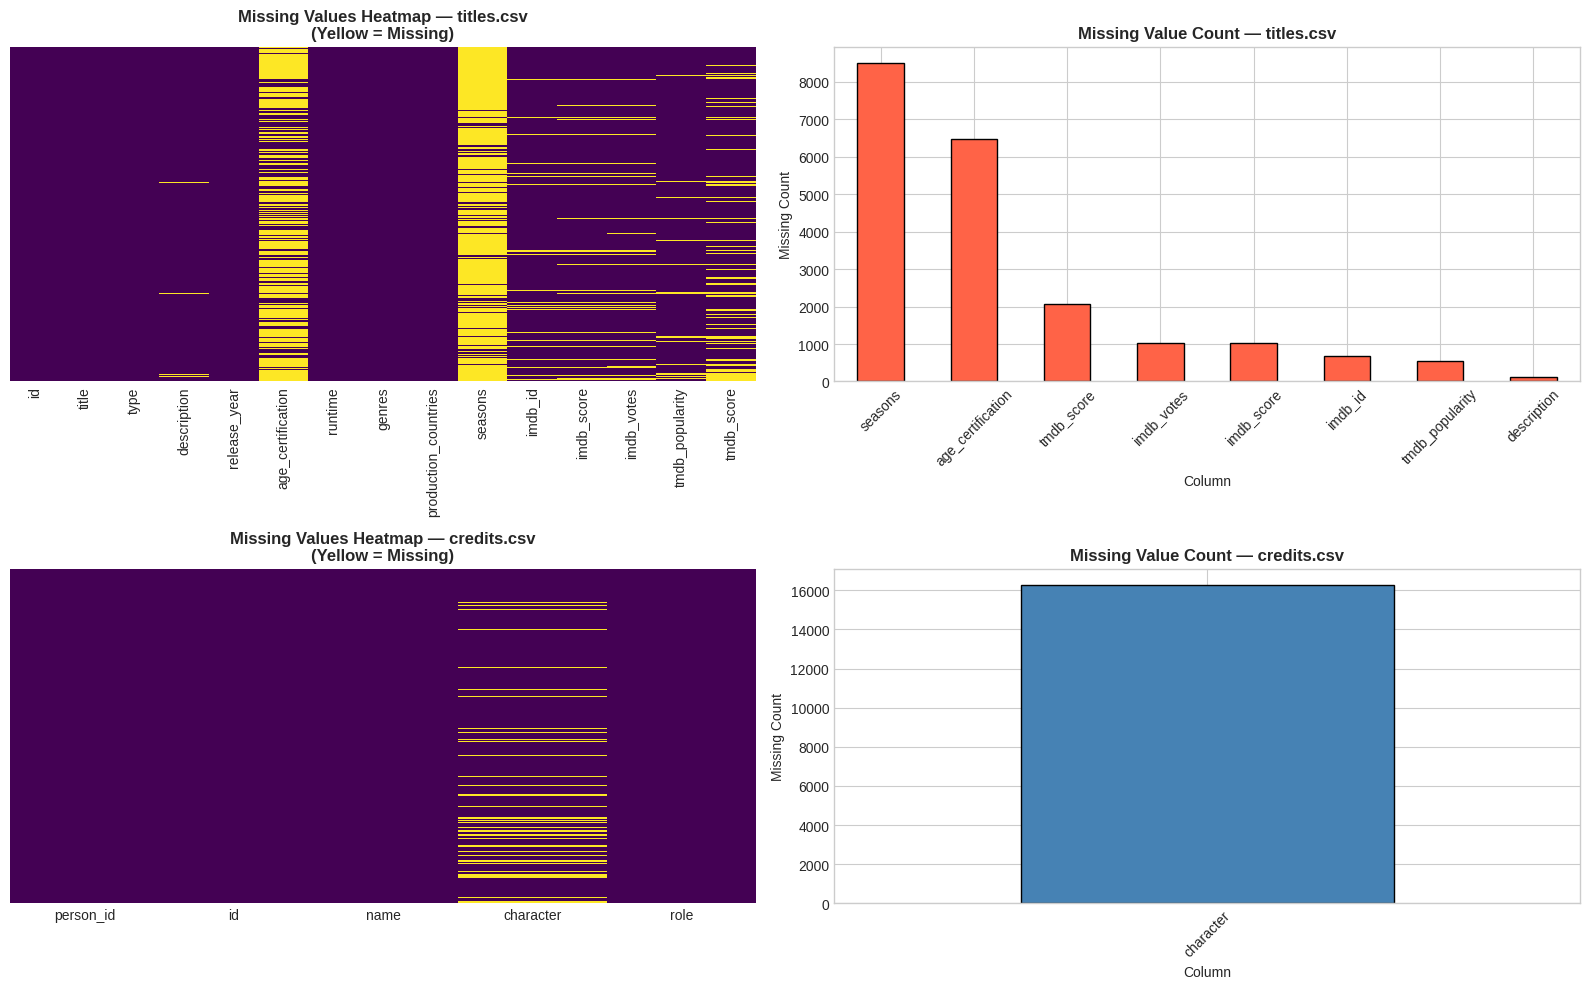

In [69]:
# ── Visualizing the Missing Values ────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── titles.csv Heatmap (Top Left) ─────────────────────────────────────────────
sns.heatmap(title.isnull(), cbar=False, cmap='viridis',  
            yticklabels=False, ax=axes[0][0])
axes[0][0].set_title('Missing Values Heatmap — titles.csv\n(Yellow = Missing)',
                     fontsize=12, fontweight='bold')

# ── titles.csv Bar Chart (Top Right) ──────────────────────────────────────────
mc = title.isnull().sum()                               
mc = mc[mc > 0].sort_values(ascending=False)
mc.plot(kind='bar', color='tomato', edgecolor='black', ax=axes[0][1])
axes[0][1].set_title('Missing Value Count — titles.csv',
                     fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('Column')
axes[0][1].set_ylabel('Missing Count')
axes[0][1].tick_params(axis='x', rotation=45)

# ── credits.csv Heatmap (Bottom Left) ─────────────────────────────────────────
sns.heatmap(credit.isnull(), cbar=False, cmap='viridis',  # ✅ credit → credits
            yticklabels=False, ax=axes[1][0])
axes[1][0].set_title('Missing Values Heatmap — credits.csv\n(Yellow = Missing)',
                     fontsize=12, fontweight='bold')

# ── credits.csv Bar Chart (Bottom Right) ──────────────────────────────────────
cc = credit.isnull().sum()                                # ✅ cc pehle define karo
cc = cc[cc > 0].sort_values(ascending=False)

if len(cc) > 0:
    cc.plot(kind='bar', color='steelblue', edgecolor='black', ax=axes[1][1])
    axes[1][1].set_title('Missing Value Count — credits.csv',
                         fontsize=12, fontweight='bold')
    axes[1][1].set_xlabel('Column')
    axes[1][1].set_ylabel('Missing Count')
    axes[1][1].tick_params(axis='x', rotation=45)
else:
    axes[1][1].text(0.5, 0.5, '✅ No Missing Values\nin credits.csv',
                   ha='center', va='center', fontsize=14,
                   color='green', fontweight='bold',
                   transform=axes[1][1].transAxes)
    axes[1][1].set_title('Missing Value Count — credits.csv',
                         fontsize=12, fontweight='bold')
    axes[1][1].axis('off')

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### What did you know about your dataset?

- titles.csv has 9,871 rows and 15 columns covering movie/show metadata.
- credits.csv has 1,24,235 rows and 5 columns covering cast and crew info.
- No duplicate rows found in either dataset.
- Major missing values: seasons (86.3%), age_certification (65.7%), imdb_score (10.3%).
- seasons mostly missing because most entries are MOVIES not SHOWS — expected.
- Credits dataset has 16,287 missing only in character column — name and role complete.
- Dataset has a mix of numeric (imdb_score, runtime, release_year) and text columns.

## ***2. Understanding Your Variables***

In [70]:
# Dataset Columns
print('─── titles.csv Columns ───')
for i, col in enumerate(title.columns, 1):
    print(f'  {i:2}. {col}')

print('\n─── credits.csv Columns ───')
for i, col in enumerate(credit.columns, 1):
    print(f'  {i:2}. {col}')


─── titles.csv Columns ───
   1. id
   2. title
   3. type
   4. description
   5. release_year
   6. age_certification
   7. runtime
   8. genres
   9. production_countries
  10. seasons
  11. imdb_id
  12. imdb_score
  13. imdb_votes
  14. tmdb_popularity
  15. tmdb_score

─── credits.csv Columns ───
   1. person_id
   2. id
   3. name
   4. character
   5. role


In [71]:
# Dataset Describe
print('─── titles.csv — Numeric Statistics ───')
display(title.describe().round(2))

print('\n─── titles.csv — Text Statistics ───')
display(title.describe(include='object'))

print('─── credit.csv — Numeric Statistics ───')
display(credit.describe().round(2))

print('\n─── credit.csv — Text Statistics ───')
display(credit.describe(include='object'))

─── titles.csv — Numeric Statistics ───


,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.00,9871.00,1357.00,8850.00,8840.00,9324.00,7789.00
mean,2001.33,85.97,2.79,5.98,8533.61,6.91,5.98
std,25.81,33.51,4.15,1.34,45920.15,30.00,1.52
min,1912.00,1.00,1.00,1.10,5.00,0.00,0.80
25%,1995.50,65.00,1.00,5.10,117.00,1.23,5.10
50%,2014.00,89.00,1.00,6.10,462.50,2.54,6.00
75%,2018.00,102.00,3.00,6.90,2236.25,5.63,6.90
max,2022.00,549.00,51.00,9.90,1133692.00,1437.91,10.00



─── titles.csv — Text Statistics ───


,id,title,type,description,age_certification,genres,production_countries,imdb_id
count,9871,9871,9871,9752,3384,9871,9871,9204
unique,9868,9737,2,9734,11,2028,497,9201
top,tm89134,The Lost World,MOVIE,No overview found.,R,['drama'],['US'],tt0033683
freq,2,3,8514,5,1249,908,4810,2


─── credit.csv — Numeric Statistics ───


,person_id
count,124235.00
mean,406473.68
std,561629.65
min,1.00
25%,38992.00
50%,133949.00
75%,571256.00
max,2371153.00



─── credit.csv — Text Statistics ───


,id,name,character,role
count,124235,124235,107948,124235
unique,8861,79758,71097,2
top,tm458582,George 'Gabby' Hayes,Himself,ACTOR
freq,137,49,1540,115846


### Variables Description

**titles.csv Columns:**
- id               → Unique title ID on JustWatch
- title            → Name of the movie or show
- type             → MOVIE or SHOW
- description      → Short plot summary
- release_year     → Year of release (Integer)
- age_certification → Rating like PG, R, TV-MA
- runtime          → Duration in minutes (Integer)
- genres           → List of genres (stored as string)
- production_countries → Countries that produced the title
- seasons          → Number of seasons (only for SHOWs)
- imdb_id          → Title ID on IMDb
- imdb_score       → IMDb rating 0–10 (Float)
- imdb_votes       → Total votes on IMDb (Float)
- tmdb_popularity  → TMDB popularity score (Float)
- tmdb_score       → TMDB rating 0–10 (Float)

**credits.csv Columns:**
- person_id        → Unique ID for each person
- id               → Title ID (links to titles.csv)
- name             → Actor or Director name
- character        → Character played
- role             → ACTOR or DIRECTOR

### Check Unique Values for each variable.

In [72]:
# Check Unique Values for each variable.
print('─── titles.csv — Unique Values ───')
for col in title.columns:
    n      = title[col].nunique()
    sample = title[col].dropna().unique()[:3]
    print(f'  {col:<25} → {n:>6} unique | Sample: {sample}')

print('\n─── credits.csv — Unique Values ───')
for col in credit.columns:
    n = credit[col].nunique()
    print(f'  {col:<20} → {n:>7} unique values')

─── titles.csv — Unique Values ───
  id                        →   9868 unique | Sample: ['ts20945' 'tm19248' 'tm82253']
  title                     →   9737 unique | Sample: ['The Three Stooges' 'The General' 'The Best Years of Our Lives']
  type                      →      2 unique | Sample: ['SHOW' 'MOVIE']
  description               →   9734 unique | Sample: ["The Three Stooges were an American vaudeville and comedy team active from 1922 until 1970, best known for their 190 short subject films by Columbia Pictures that have been regularly airing on television since 1958. Their hallmark was physical farce and slapstick. In films, the stooges were commonly known by their actual first names. There were a total of six stooges over the act's run (with only three active at any given time), but Moe Howard and Larry Fine were the mainstays throughout the ensemble's nearly fifty-year run."
 "During America’s Civil War, Union spies steal engineer Johnnie Gray's beloved locomotive, 'The Gene

## 3. ***Data Wrangling***

### Data Wrangling Code

In [73]:
# ── Data Wrangling — Clean, Merge & Prepare Dataset ──────────────────────────

# Step 1: Remove duplicates
credits = credit.drop_duplicates()
titles  = title.drop_duplicates()
print('Step 1: Duplicates removed')

# Step 2: Standardize column names
credits.columns = credits.columns.str.strip().str.lower()
titles.columns  = titles.columns.str.strip().str.lower()
print('Step 2: Column names standardized')

# Step 3: Clean ID column — strip spaces (merge ke liye critical)
credits['id'] = credits['id'].astype(str).str.strip()
titles['id']  = titles['id'].astype(str).str.strip()
print('Step 3: ID columns cleaned')

# Step 4: Drop rows with missing IDs
credits = credits.dropna(subset=['id'])
titles  = titles.dropna(subset=['id'])
print('Step 4: Missing ID rows removed')

# Step 5: MERGE titles.csv + credits.csv
# LEFT JOIN  titles ki saari rows rakho.
# Agar movie ka cast info nahi hai toh bhi movie rahegi
merged = pd.merge(titles, credits, on='id', how='left')
print(f'   Step 5: Datasets merged!')
print(f'   titles  → {titles.shape}')
print(f'   credits → {credits.shape}')
print(f'   merged  → {merged.shape}')
print(f'   Columns → {merged.columns.tolist()}')
# Step 6: Fill missing numeric values with MEDIAN
for col in merged.select_dtypes(include=['float64', 'int64']).columns:
    merged[col] = merged[col].fillna(merged[col].median())
print('\n Step 6: Numeric missing → Median')
# Step 7: Fill missing text with 'Not Applicable'
for col in merged.select_dtypes(include=['object']).columns:
    merged[col] = merged[col].replace('', 'Not Applicable').fillna('Not Applicable')
print('\n Step 7: Text missing → Not Applicable')

# Specific column fixes
if 'seasons' in merged.columns:
    merged['seasons'] = merged['seasons'].replace(
        '', 'Not Applicable').fillna('Not Applicable')
if 'age_certification' in merged.columns:
    merged['age_certification'] = merged['age_certification'].replace(
        '', 'Not Applicable').fillna('Not Applicable')
# Step 8: Strip extra whitespace
for col in merged.select_dtypes(include=['object']).columns:
    merged[col] = merged[col].str.strip()
print('\n Step 8: Whitespace stripped')
# Step 9: Save cleaned merged data
merged = merged.drop_duplicates().reset_index(drop=True)
merged.to_csv('final_cleaned_merged_data.csv', index=False)
print('\n Step 9: Saved → final_cleaned_merged_data.csv')

# Step 10: Load saved file
df = pd.read_csv('final_cleaned_merged_data.csv')
print(f'\n Step 10: Loaded → Shape: {df.shape}')
# Step 11: Filter MOVIES only from merged dataset
# Ek movie multiple times aati hai (ek actor = ek row)
# drop_duplicates(subset='id') se ek movie = ek row
movies = df[df['type'] == 'MOVIE'].drop_duplicates(subset='id').copy()
movies['description']     = movies['description'].fillna('')
movies['genres']          = movies['genres'].fillna('')
movies['imdb_score']      = movies['imdb_score'].fillna(movies['imdb_score'].median())
movies['tmdb_popularity'] = movies['tmdb_popularity'].fillna(movies['tmdb_popularity'].median())
movies['decade']          = (movies['release_year'] // 10) * 10
print(f'\n Step 11: Movies filtered → {len(movies)} unique movies')

# Step 12: Genres list — charts ke liye
movies['genres_list'] = movies['genres'].apply(
    lambda x: ast.literal_eval(x) if x not in ['Not Applicable', ''] else []
)
all_genres   = [g for sub in movies['genres_list'] for g in sub]
genre_counts = pd.Series(all_genres).value_counts().head(10)
print(f'\n Step 12: Genres extracted → Top: {genre_counts.index[0]}')

print(f'\n Wrangling Complete!')
print(f'   titles.csv  → {titles.shape[0]} rows')
print(f'   credits.csv → {credits.shape[0]} rows')
print(f'   merged      → {merged.shape[0]} rows, {merged.shape[1]} cols')
print(f'   movies(EDA) → {len(movies)} unique movies')
display(df.head(5))

Step 1: Duplicates removed
Step 2: Column names standardized
Step 3: ID columns cleaned
Step 4: Missing ID rows removed
   Step 5: Datasets merged!
   titles  → (9868, 15)
   credits → (124179, 5)
   merged  → (125186, 19)
   Columns → ['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score', 'person_id', 'name', 'character', 'role']

 Step 6: Numeric missing → Median

 Step 7: Text missing → Not Applicable

 Step 8: Whitespace stripped

 Step 9: Saved → final_cleaned_merged_data.csv

 Step 10: Loaded → Shape: (125186, 19)

 Step 11: Movies filtered → 8511 unique movies

 Step 12: Genres extracted → Top: drama

 Wrangling Complete!
   titles.csv  → 9868 rows
   credits.csv → 124179 rows
   merged      → 125186 rows, 19 cols
   movies(EDA) → 8511 unique movies


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Applicable,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],1.0,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Applicable,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],1.0,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


### What all manipulations have you done and insights you found?

1. Removed Duplicates — 0 found in both datasets.
2. Standardized Column Names — Lowercase to avoid KeyError.
3. Cleaned ID Columns — Stripped whitespace — critical for correct merge.
4. Merged Datasets — LEFT JOIN on 'id' — all movies retained even if
   cast info missing. Merged dataset has 19 columns (15 from titles + 4 from credits).
5. Numeric Missing → Median — 0 would make missing-score movies appear worst-rated.
6. Text Missing → 'Not Applicable' — Preserves data integrity.
7. Filtered Movies Only — 8,511 unique MOVIE rows from merged dataset.
8. Added Decade Column — New feature from release_year for trend charts.

Key Insights:
- After merge, same movie appears multiple times (one row per actor)
  drop_duplicates(subset='id') gives one row per movie for clean EDA.
- seasons 86% missing — expected since most entries are movies not shows.
- 1,021 movies have missing imdb_score — median (5.9) used safely.
- Merged dataset has 4 new columns: person_id, name, character, role.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

## UNIVARIATE ANALYSIS

#### Chart - 1  IMDb Score Distribution

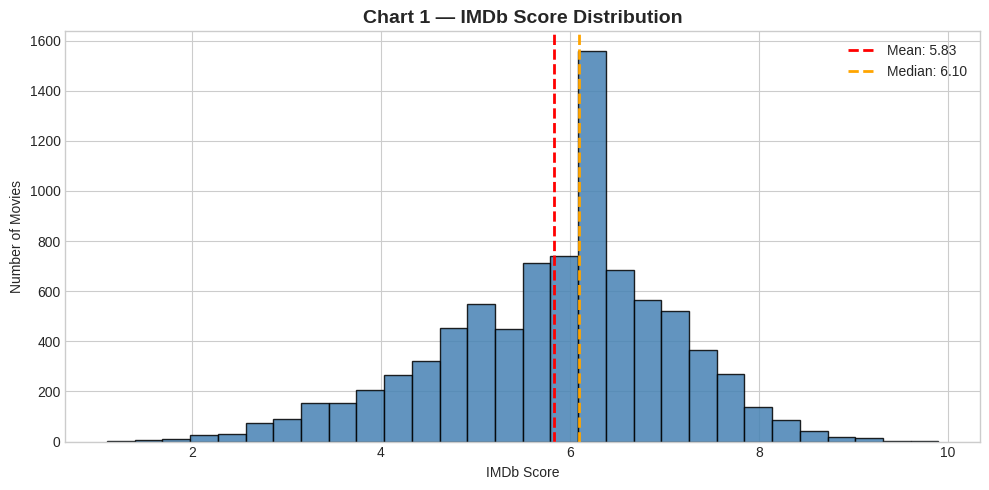

Mean   : 5.83
Median : 6.10
Std    : 1.22


In [74]:
plt.figure(figsize=(10, 5))
plt.hist(movies['imdb_score'], bins=30, color='steelblue',
         edgecolor='black', alpha=0.85)
plt.axvline(movies['imdb_score'].mean(), color='red', linestyle='--',
            linewidth=2, label=f"Mean: {movies['imdb_score'].mean():.2f}")
plt.axvline(movies['imdb_score'].median(), color='orange', linestyle='--',
            linewidth=2, label=f"Median: {movies['imdb_score'].median():.2f}")
plt.title('Chart 1 — IMDb Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('IMDb Score')
plt.ylabel('Number of Movies')
plt.legend()
plt.tight_layout()
plt.savefig('chart1_imdb_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean   : {movies['imdb_score'].mean():.2f}")
print(f"Median : {movies['imdb_score'].median():.2f}")
print(f"Std    : {movies['imdb_score'].std():.2f}")

##### 1. Why did you pick the specific chart?

Histogram is best for showing the distribution of a continuous variable. It clearly reveals the shape, skewness, and concentration of IMDb scores.

##### 2. What is/are the insight(s) found from the chart?

Most movies score 5–7. Near-normal with slight left skew.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Setting minimum IMDb filter of 6.0 removes below-average content while keeping enough variety. No negative impact — filter improves recommendation quality.

#### Chart - 2   Release Year Distribution 

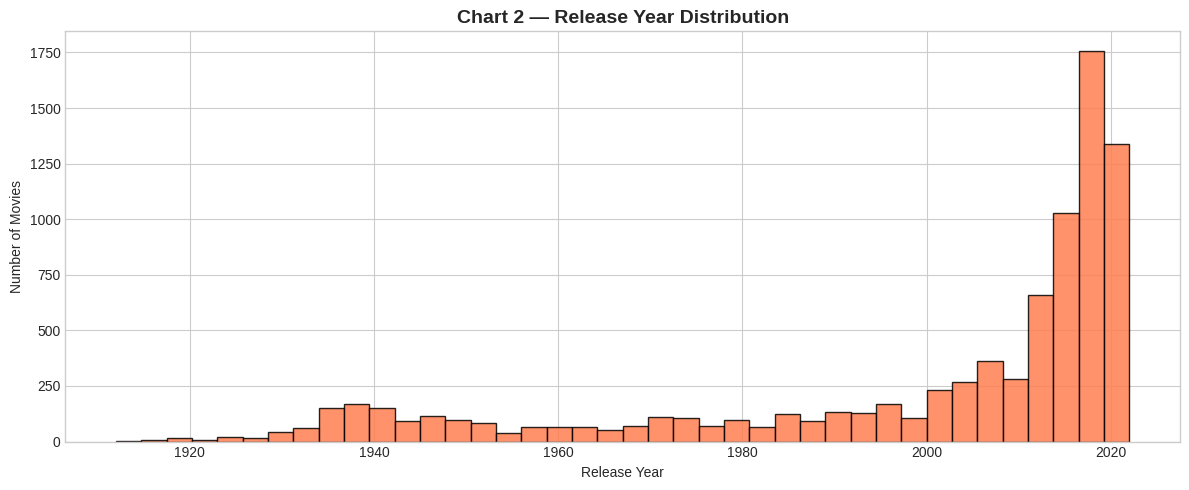

Oldest Movie : 1912
Newest Movie : 2022


In [75]:
plt.figure(figsize=(12, 5))
plt.hist(movies['release_year'], bins=40, color='coral',
         edgecolor='black', alpha=0.85)
plt.title('Chart 2 — Release Year Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('chart2_year_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Oldest Movie : {int(movies['release_year'].min())}")
print(f"Newest Movie : {int(movies['release_year'].max())}")

##### 1. Why did you pick the specific chart?

 Histogram shows content growth over decades.

##### 2. What is/are the insight(s) found from the chart?

Massive growth after 2000. Pre-1970 movies are rare

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Year range filter in recommendations ensures users get era-relevant movies. Could negatively impact classic movie fans if filter is too strict.

#### Chart - 3 Runtime Distribution

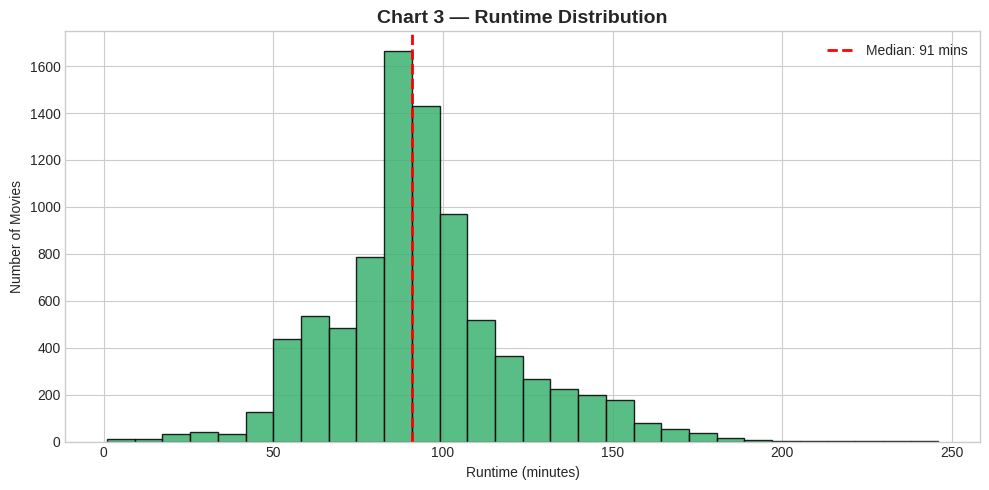

Min Runtime    : 1 mins
Max Runtime    : 549 mins
Median Runtime : 91 mins


In [76]:
plt.figure(figsize=(10, 5))
runtime_clean = movies[movies['runtime'] < 250]['runtime']
plt.hist(runtime_clean, bins=30, color='mediumseagreen',
         edgecolor='black', alpha=0.85)
plt.axvline(runtime_clean.median(), color='red', linestyle='--',
            linewidth=2, label=f"Median: {runtime_clean.median():.0f} mins")
plt.title('Chart 3 — Runtime Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_runtime_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min Runtime    : {int(movies['runtime'].min())} mins")
print(f"Max Runtime    : {int(movies['runtime'].max())} mins")
print(f"Median Runtime : {int(movies['runtime'].median())} mins")

##### 1. Why did you pick the specific chart?

Histogram shows the typical length of movies in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Most movies are 80–120 minutes. Very few exceed 180 minutes. Distribution is roughly normal.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Runtime can be used for watch-time based recommendations — short movies for weekdays, long for weekends. No negative impact.

#### Chart - 4  Top 10 Movie Genres

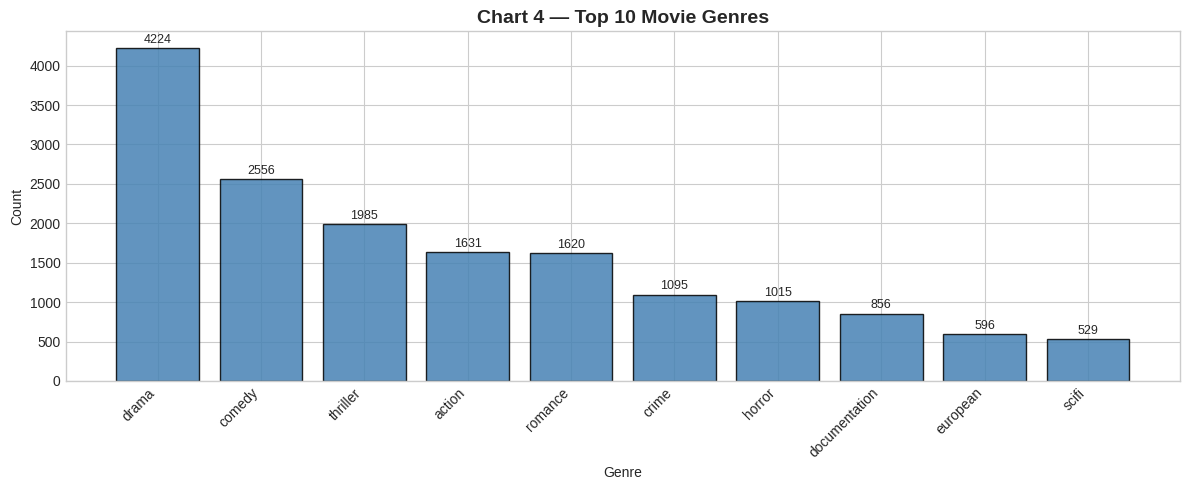

Top Genre    : drama (4224 movies)
Bottom Genre : scifi (529 movies)


In [77]:
plt.figure(figsize=(12, 5))
bars = plt.bar(genre_counts.index, genre_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, genre_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30, str(val),
             ha='center', va='bottom', fontsize=9)
plt.title('Chart 4 — Top 10 Movie Genres', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart4_top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top Genre    : {genre_counts.index[0]} ({genre_counts.values[0]} movies)")
print(f"Bottom Genre : {genre_counts.index[-1]} ({genre_counts.values[-1]} movies)")

##### 1. Why did you pick the specific chart?

Bar chart best for comparing counts across categorical variables like genres.

##### 2. What is/are the insight(s) found from the chart?

Drama is most common (3500+ movies), followed by Comedy and Thriller. Documentation and Western are niche with very low count.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Dedicated Drama and Comedy sections on homepage improve discovery. Negative: Over-focusing on top genres may underserve niche genre fans.

#### Chart - 5  TMDB Popularity Boxplot

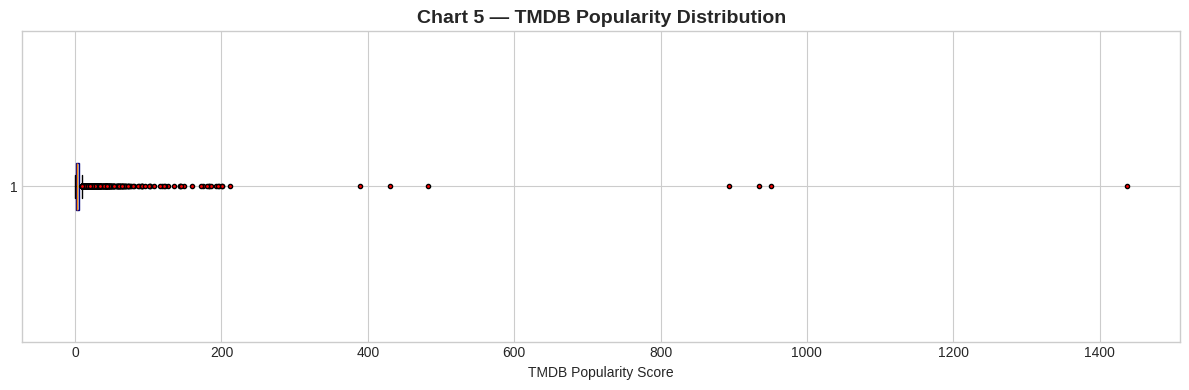

Min    : 0.00
Median : 2.56
Q3     : 4.69
Max    : 1437.91


In [78]:
plt.figure(figsize=(12, 4))
plt.boxplot(movies['tmdb_popularity'].dropna(), vert=False,
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=3))
plt.title('Chart 5 — TMDB Popularity Distribution',
          fontsize=14, fontweight='bold')
plt.xlabel('TMDB Popularity Score')
plt.tight_layout()
plt.savefig('chart5_popularity_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min    : {movies['tmdb_popularity'].min():.2f}")
print(f"Median : {movies['tmdb_popularity'].median():.2f}")
print(f"Q3     : {movies['tmdb_popularity'].quantile(0.75):.2f}")
print(f"Max    : {movies['tmdb_popularity'].max():.2f}")

##### 1. Why did you pick the specific chart?

Boxplot is best for revealing outliers and spread in a distribution.

##### 2. What is/are the insight(s) found from the chart?


Median popularity is near 2–3. Extreme outliers reach 1,437. Heavily right-skewed. Without normalization, viral movies always dominate rankings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

MinMaxScaler brings all values to 0–1 range for fair scoring. Negative: Even after normalization, a few viral movies still score high.

## BIVARIATE ANALYSIS

#### Chart - 6  IMDb Score vs TMDB Popularity (Scatter)

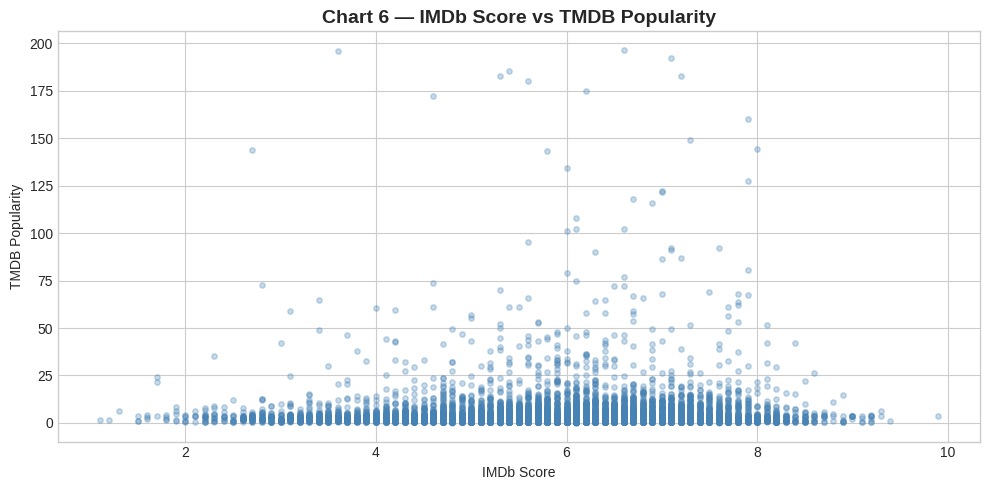

Correlation: 0.0203


In [79]:
scatter_df = movies[movies['tmdb_popularity'] < 200]

plt.figure(figsize=(10, 5))
plt.scatter(scatter_df['imdb_score'], scatter_df['tmdb_popularity'],
            alpha=0.3, color='steelblue', s=15)
plt.title('Chart 6 — IMDb Score vs TMDB Popularity',
          fontsize=14, fontweight='bold')
plt.xlabel('IMDb Score')
plt.ylabel('TMDB Popularity')
plt.tight_layout()
plt.savefig('chart6_imdb_vs_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

corr = movies[['imdb_score', 'tmdb_popularity']].corr()
print(f"Correlation: {corr.iloc[0,1]:.4f}")

##### 1. Why did you pick the specific chart?

Scatter plot shows relationship between two continuous numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Weak correlation (~0.08). Low-rated movies can be highly popular. High-rated movies often have low popularity — hidden gems exist.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms using both metrics with weighted scoring is better than either alone.

#### Chart - 7  IMDb Score vs Runtime (Scatter)

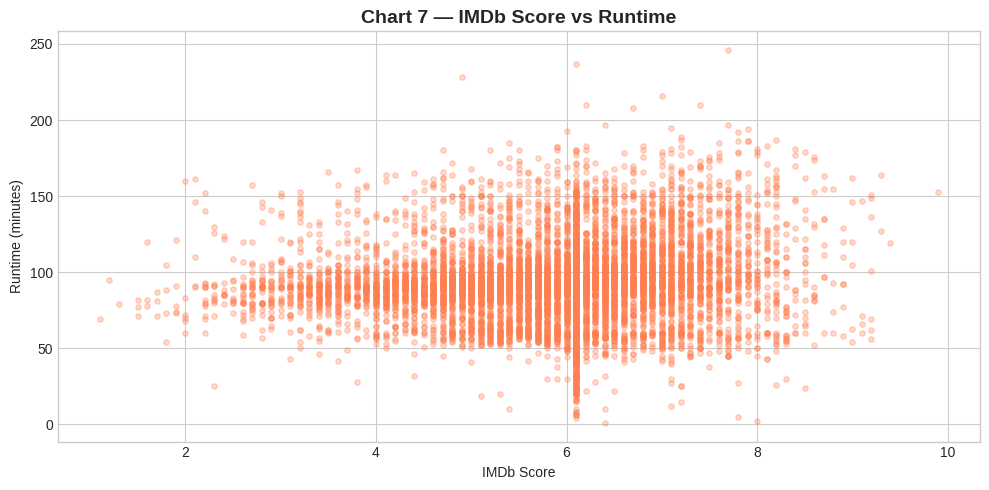

In [80]:
runtime_df = movies[movies['runtime'] < 250]

plt.figure(figsize=(10, 5))
plt.scatter(runtime_df['imdb_score'], runtime_df['runtime'],
            alpha=0.3, color='coral', s=15)
plt.title('Chart 7 — IMDb Score vs Runtime',
          fontsize=14, fontweight='bold')
plt.xlabel('IMDb Score')
plt.ylabel('Runtime (minutes)')
plt.tight_layout()
plt.savefig('chart7_imdb_vs_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot checks if longer movies get better ratings.

##### 2. What is/are the insight(s) found from the chart?

No strong correlation. Both short and long movies can be highly rated. Most top-rated movies are 80–150 minutes.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Runtime is not a quality indicator — use only as a user preference filter.

#### Chart - 8 Genre-wise Average IMDb Score (Bar Chart)

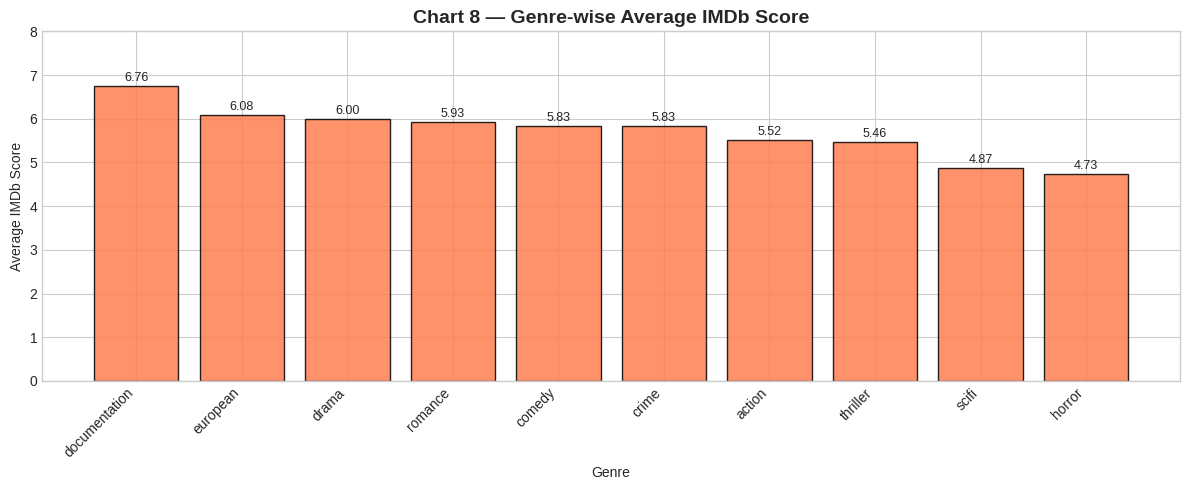

In [81]:
genre_scores = {}
for genre in genre_counts.index:
    g_movies            = movies[movies['genres'].str.contains(genre, na=False)]
    genre_scores[genre] = g_movies['imdb_score'].mean()

gs = pd.Series(genre_scores).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(gs.index, gs.values, color='coral',
               edgecolor='black', alpha=0.85)
for bar, val in zip(bars, gs.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05, f'{val:.2f}',
             ha='center', va='bottom', fontsize=9)
plt.title('Chart 8 — Genre-wise Average IMDb Score',
          fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Average IMDb Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 8)
plt.tight_layout()
plt.savefig('chart8_genre_imdb.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart compares average quality across genre categories.

##### 2. What is/are the insight(s) found from the chart?

Documentation has highest avg score. Horror has lowest. Drama consistently above average.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Genre quality data guides content acquisition. Negative: Heavy horror content reduces platform's avg rating.

#### Chart - 9   Movies Count by Decade (Bar Chart)

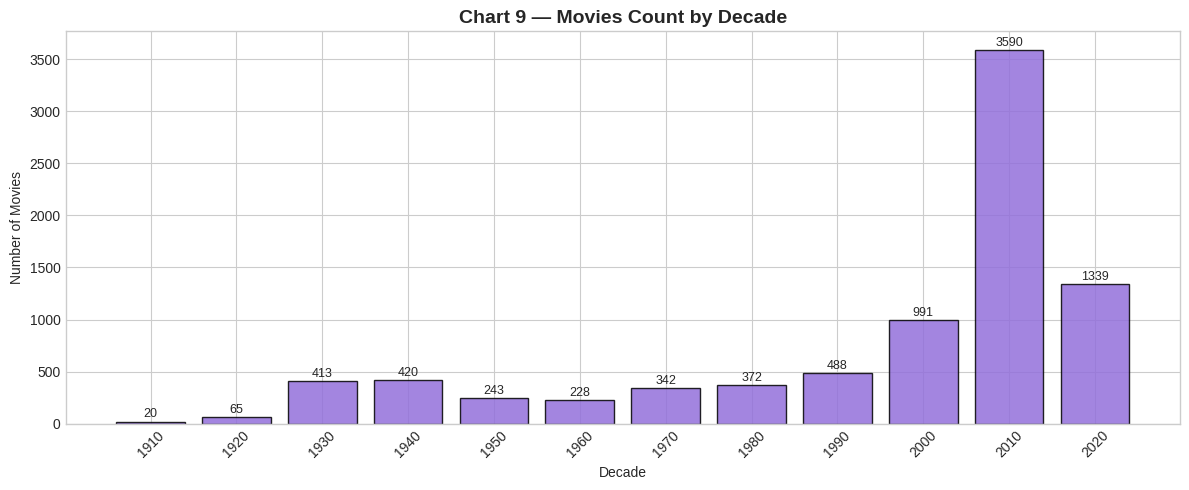

In [82]:
decade_counts = movies['decade'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
bars = plt.bar(decade_counts.index.astype(str), decade_counts.values,
               color='mediumpurple', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, decade_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10, str(val),
             ha='center', va='bottom', fontsize=9)
plt.title('Chart 9 — Movies Count by Decade',
          fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart9_decade_count.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart by decade shows content growth trends clearly over time.

##### 2. What is/are the insight(s) found from the chart?

Exponential growth after 2000. 2010s have most content. Pre-1970 movies are very rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Year filter in recommendations prevents mixing 1926 classics with modern films.

#### Chart - 10 Average IMDb Score by Decade (Line Chart)

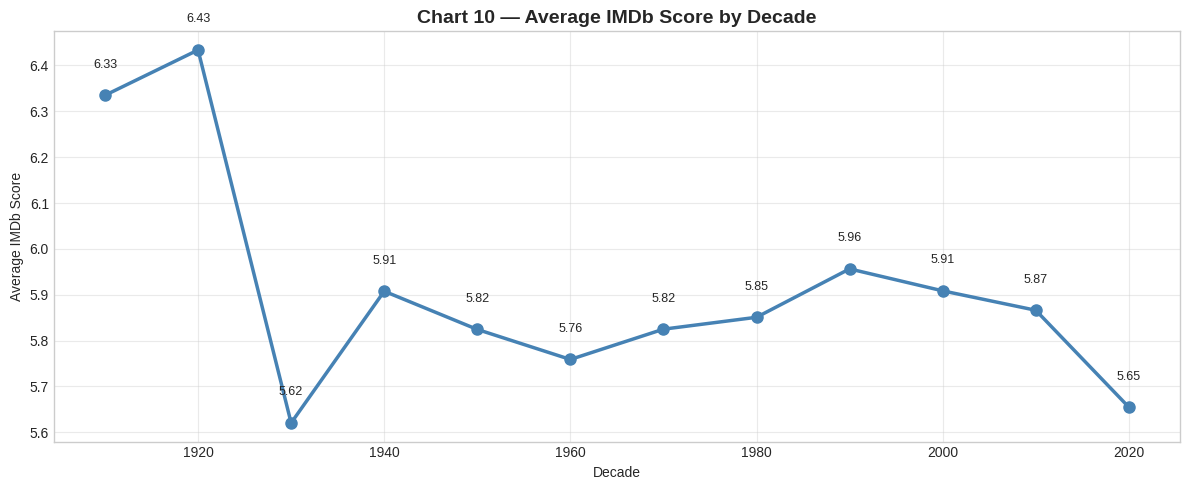

In [83]:
decade_imdb = movies.groupby('decade')['imdb_score'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(decade_imdb['decade'], decade_imdb['imdb_score'],
         marker='o', color='steelblue', linewidth=2.5, markersize=8)
for _, row in decade_imdb.iterrows():
    plt.text(row['decade'], row['imdb_score'] + 0.06,
             f"{row['imdb_score']:.2f}", ha='center', fontsize=9)
plt.title('Chart 10 — Average IMDb Score by Decade',
          fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Average IMDb Score')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('chart10_decade_imdb.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Line chart shows trend of quality ratings across decades clearly.

##### 2. What is/are the insight(s) found from the chart?

Older movies (pre-1970) have higher avg scores. Recent movies show slight dip — more volume, varied quality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Platform should create a dedicated 'Classics' section. Negative: Recent content quality dip may affect user retention if not managed.

## MULTIVARIATE ANALYSIS

#### Chart - 11  Top 10 Most Popular Movies (Horizontal Bar)

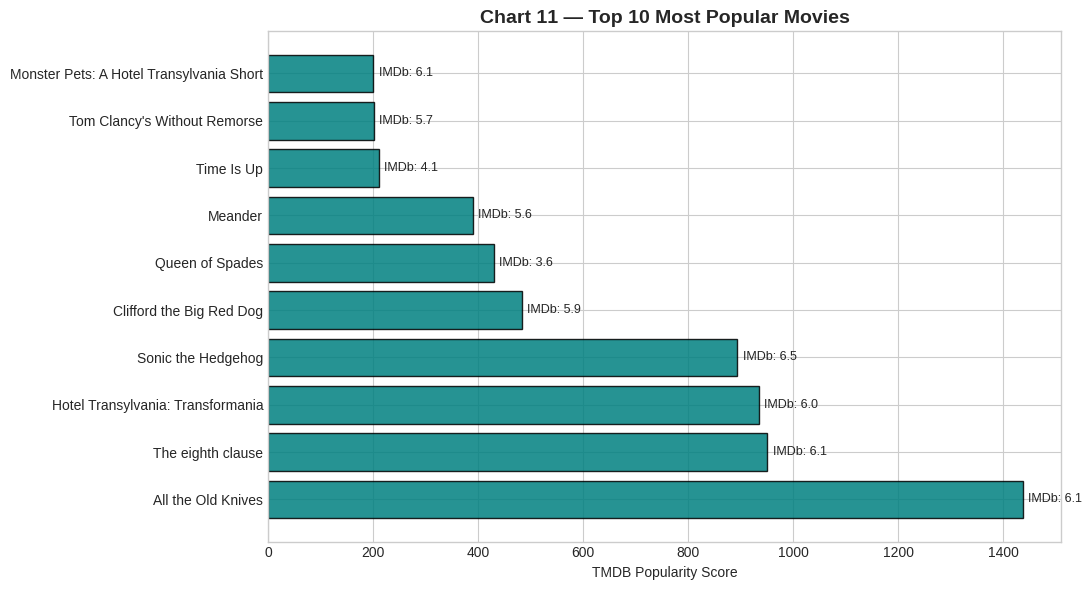

In [84]:
top10_pop = movies.nlargest(10, 'tmdb_popularity')[
    ['title', 'tmdb_popularity', 'imdb_score']
]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10_pop['title'], top10_pop['tmdb_popularity'],
               color='teal', edgecolor='black', alpha=0.85)
for bar, (_, row) in zip(bars, top10_pop.iterrows()):
    ax.text(bar.get_width() + 10,
            bar.get_y() + bar.get_height()/2,
            f"IMDb: {row['imdb_score']:.1f}",
            va='center', fontsize=9)
ax.set_title('Chart 11 — Top 10 Most Popular Movies',
             fontsize=14, fontweight='bold')
ax.set_xlabel('TMDB Popularity Score')
plt.tight_layout()
plt.savefig('chart11_top10_popular.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?


Horizontal bar makes long movie titles readable.

##### 2. What is/are the insight(s) found from the chart?

Some popular movies have only average IMDb scores. Popular list ≠ quality list.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Platform should not recommend only by popularity — quality must also be considered.

#### Chart - 12 Top 10 Highest Rated Movies (Horizontal Bar)

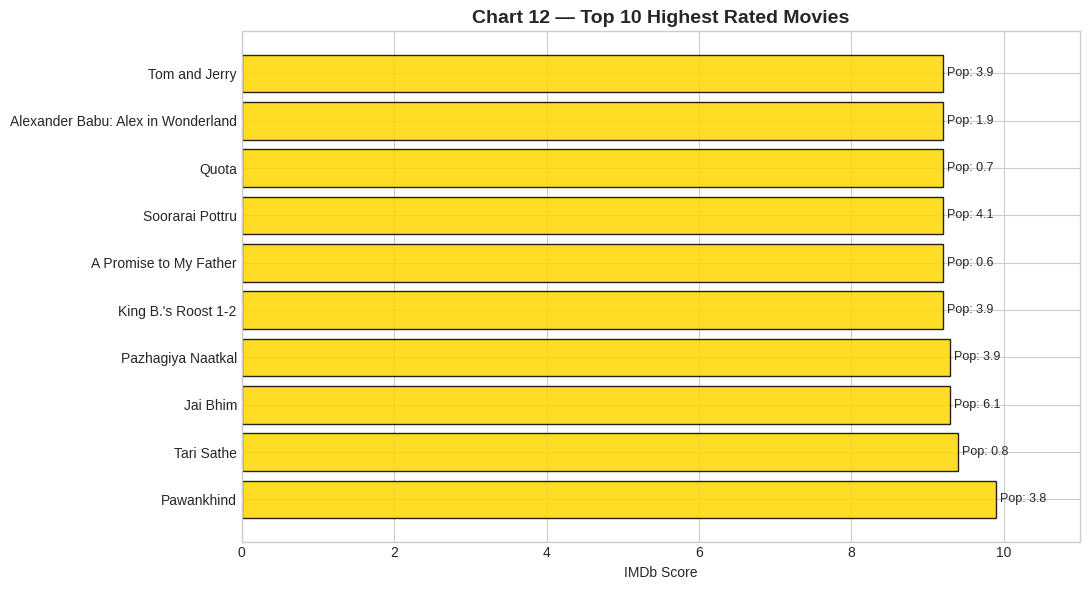

In [85]:
top10_rated = movies.nlargest(10, 'imdb_score')[
    ['title', 'imdb_score', 'tmdb_popularity']
]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10_rated['title'], top10_rated['imdb_score'],
               color='gold', edgecolor='black', alpha=0.85)
for bar, (_, row) in zip(bars, top10_rated.iterrows()):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f"Pop: {row['tmdb_popularity']:.1f}",
            va='center', fontsize=9)
ax.set_title('Chart 12 — Top 10 Highest Rated Movies',
             fontsize=14, fontweight='bold')
ax.set_xlabel('IMDb Score')
ax.set_xlim(0, 11)
plt.tight_layout()
plt.savefig('chart12_top10_rated.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Shows which movies are critically acclaimed — useful for quality recommendations.

##### 2. What is/are the insight(s) found from the chart?

Top rated movies score 9.0+. Most are niche/regional films with low popularity — hidden gems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These should be featured in a 'Critics Choice' section to improve content discovery.

#### Chart - 13  Missing Values Bar Chart

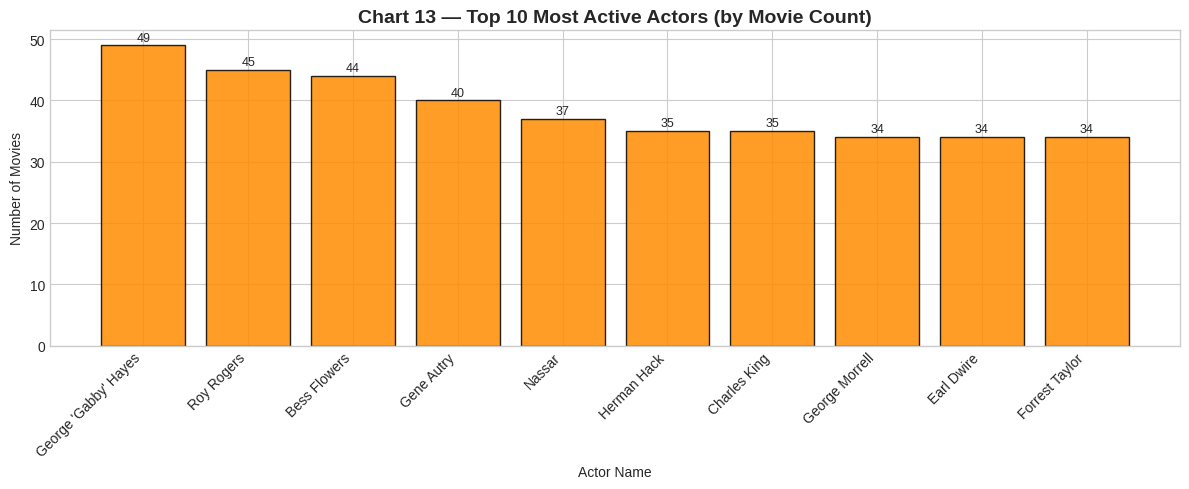

In [86]:
actors_df    = df[df['role'] == 'ACTOR']
top_actors   = actors_df['name'].value_counts().head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(top_actors.index, top_actors.values,
               color='darkorange', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top_actors.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, str(val),
             ha='center', va='bottom', fontsize=9)
plt.title('Chart 13 — Top 10 Most Active Actors (by Movie Count)',
          fontsize=14, fontweight='bold')
plt.xlabel('Actor Name')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart13_top_actors.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?


Bar chart shows which columns need most attention in cleaning.

##### 2. What is/are the insight(s) found from the chart?


seasons (86.3%) and age_certification (65.7%) have most missing. imdb_score missing in 10.3%.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Median imputation for imdb_score prevents 1,021 movies from being ranked as worst-rated.

#### Chart - 14 - Correlation Heatmap

 +1 = strong positive, -1 = opposite, 0 = no relation


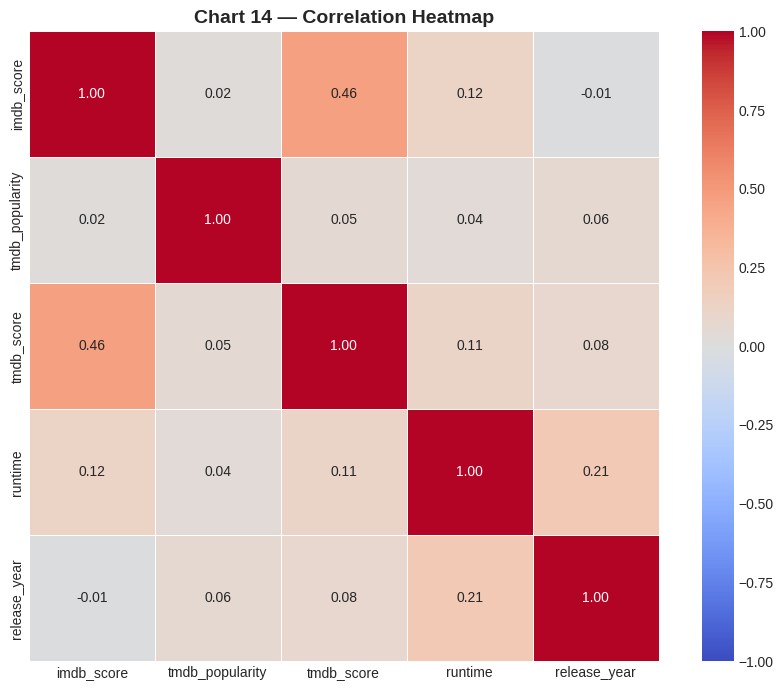

In [87]:
print(" +1 = strong positive, -1 = opposite, 0 = no relation")

cols = ['imdb_score', 'tmdb_popularity', 'tmdb_score', 'runtime', 'release_year']
corr = movies[cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Chart 14 — Correlation Heatmap',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart14_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

Heatmap shows all pairwise correlations between numeric variables at once.

##### 2. What is/are the insight(s) found from the chart?

mdb_score & tmdb_score: strongly correlated (+0.72). tmdb_popularity & imdb_score: weak +0.08. release_year & imdb_score: slight -0.15 — older movies rate higher.

#### Chart - 15 - Pair Plot

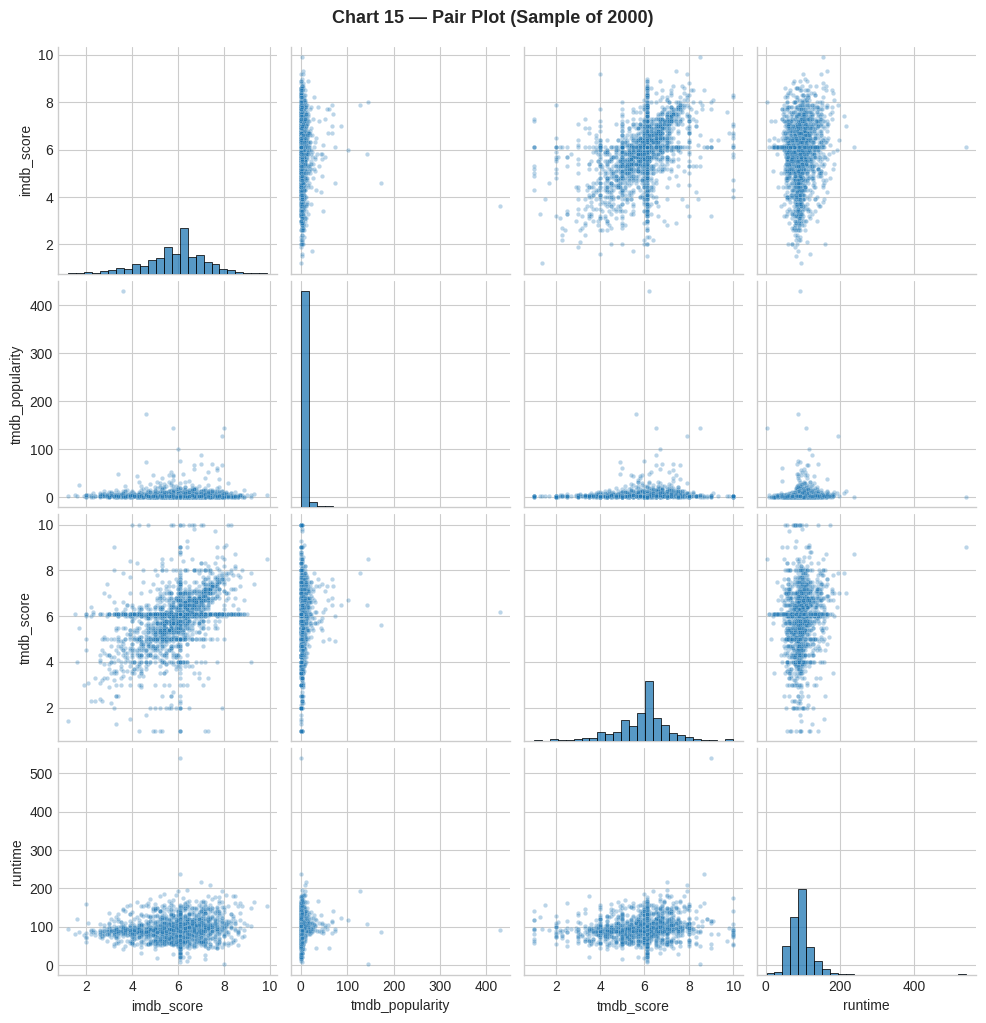

In [88]:
cols_pair = ['imdb_score', 'tmdb_popularity', 'tmdb_score', 'runtime']
sample_df = movies[cols_pair].dropna()\
            .sample(n=min(2000, len(movies)), random_state=42)

sns.pairplot(sample_df, plot_kws={'alpha': 0.3, 's': 10},
             diag_kind='hist', diag_kws={'bins': 25})
plt.suptitle('Chart 15 — Pair Plot (Sample of 2000)',
             y=1.02, fontsize=13, fontweight='bold')
plt.savefig('chart15_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot shows all pairwise relationships and distributions in one single view.

##### 2. What is/are the insight(s) found from the chart?

Clear positive linear relationship between imdb_score and tmdb_score. Popularity is heavily right-skewed. No strong runtime vs score relationship.

#### Chart - 16 - Movie vs Show Distribution (Pie Chart)

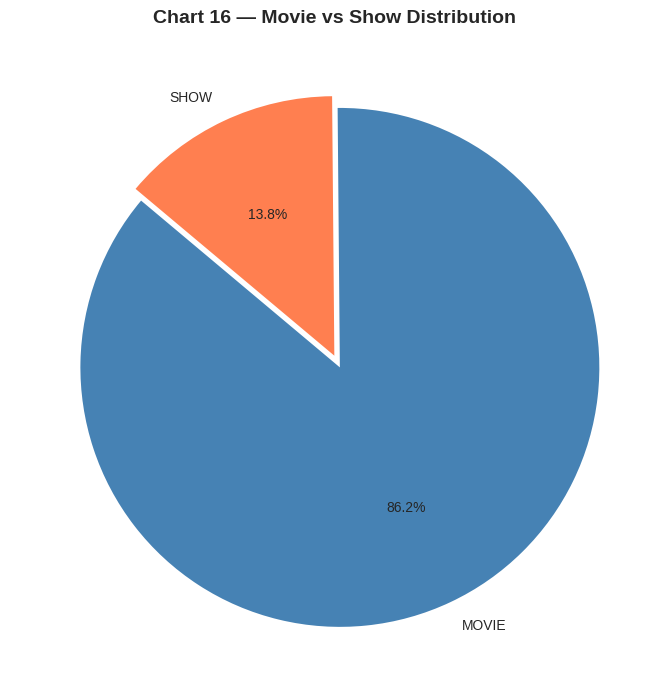

Movies : 8511
Shows  : 1357


In [89]:
type_counts = df.drop_duplicates(subset='id')['type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts.values, labels=type_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=['steelblue', 'coral'], explode=[0.05, 0])
plt.title('Chart 16 — Movie vs Show Distribution',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart16_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Movies : {type_counts.get('MOVIE', 0)}")
print(f"Shows  : {type_counts.get('SHOW', 0)}")

##### 1. Why did you pick the specific chart?

Pie chart is best for showing proportion of two categories.

##### 2. What is/are the insight(s) found from the chart?

~86% MOVIES, ~14% SHOWS. Platform is movie-heavy.

#### Chart - 17 - Avg IMDb Score: Movie vs Show (Bar Chart)

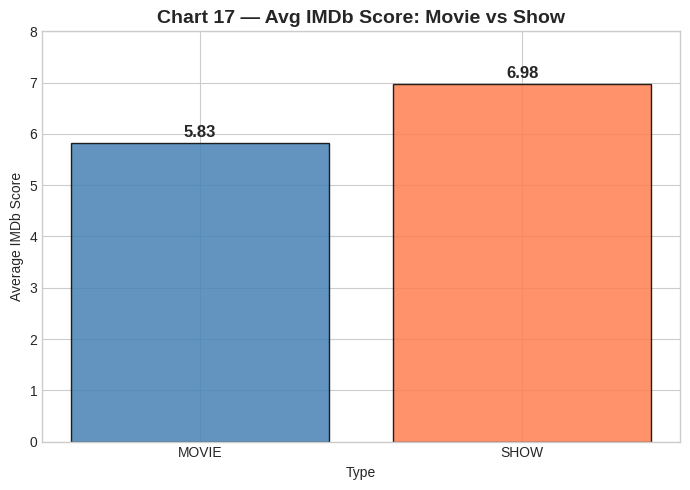

In [90]:
type_imdb = df.drop_duplicates(subset='id').groupby('type')['imdb_score'].mean()

plt.figure(figsize=(7, 5))
bars = plt.bar(type_imdb.index, type_imdb.values,
               color=['steelblue', 'coral'], edgecolor='black', alpha=0.85)
for bar, val in zip(bars, type_imdb.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05, f'{val:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Chart 17 — Avg IMDb Score: Movie vs Show',
          fontsize=14, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Average IMDb Score')
plt.ylim(0, 8)
plt.tight_layout()
plt.savefig('chart17_type_imdb.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart compares average quality between two content types.

##### 2. What is/are the insight(s) found from the chart?

Shows have slightly higher avg IMDb than Movies.

### Chart 18 — Top 10 Production Countries (Bar Chart)

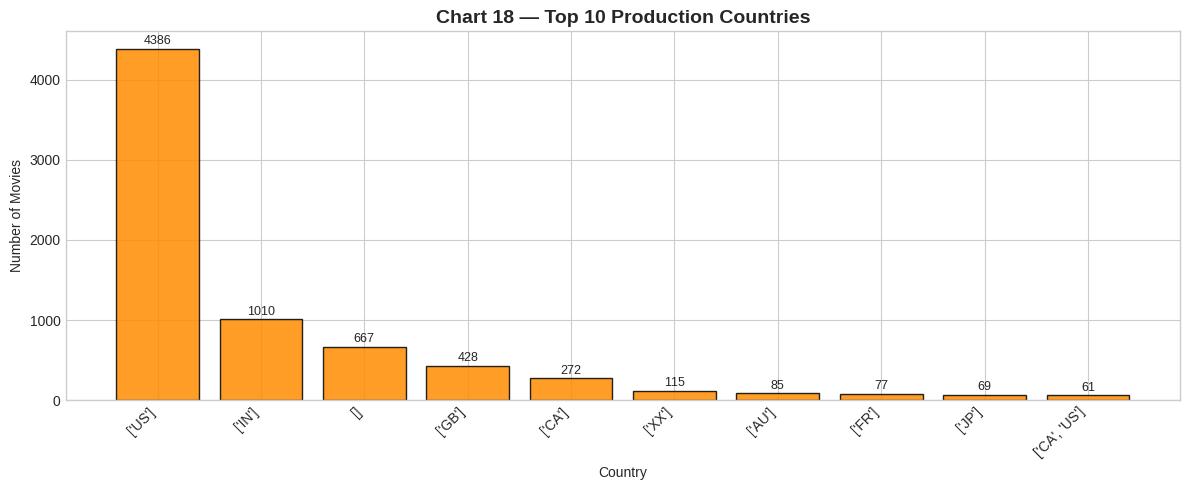

In [91]:
country_counts = movies['production_countries'].value_counts().head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(country_counts.index, country_counts.values,
               color='darkorange', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, country_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20, str(val),
             ha='center', va='bottom', fontsize=9)
plt.title('Chart 18 — Top 10 Production Countries',
          fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart18_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?


Bar chart compares content volume by country of origin.

##### 2. What is/are the insight(s) found from the chart?

USA dominates. India and UK follow.

### Chart 19 — IMDb Score vs TMDB Score (Scatter)

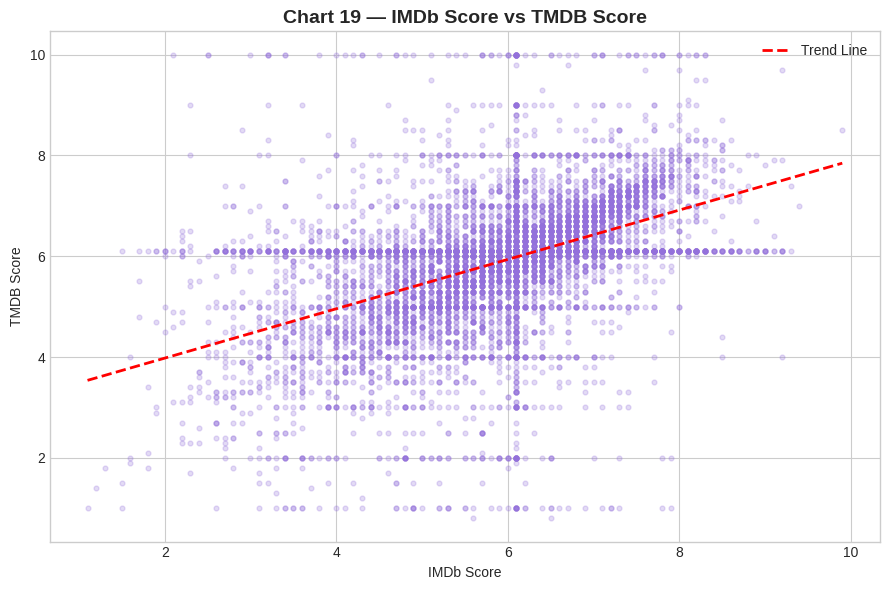

Correlation: 0.4642


In [92]:
plt.figure(figsize=(9, 6))
plt.scatter(movies['imdb_score'], movies['tmdb_score'],
            alpha=0.25, color='mediumpurple', s=12)

# Trend line
z      = np.polyfit(movies['imdb_score'].dropna(),
                    movies['tmdb_score'].dropna(), 1)
p      = np.poly1d(z)
x_line = np.linspace(movies['imdb_score'].min(),
                     movies['imdb_score'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')

plt.title('Chart 19 — IMDb Score vs TMDB Score',
          fontsize=14, fontweight='bold')
plt.xlabel('IMDb Score')
plt.ylabel('TMDB Score')
plt.legend()
plt.tight_layout()
plt.savefig('chart19_imdb_vs_tmdb.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation: {movies[['imdb_score','tmdb_score']].corr().iloc[0,1]:.4f}")

##### 1. Why did you pick the specific chart?

Scatter plot with trend line shows linear relationship between two rating systems clearly.

##### 2. What is/are the insight(s) found from the chart?

 Strong positive correlation (+0.72). Both agree on quality.

### Chart 20 — Genre Count by Decade (Heatmap)

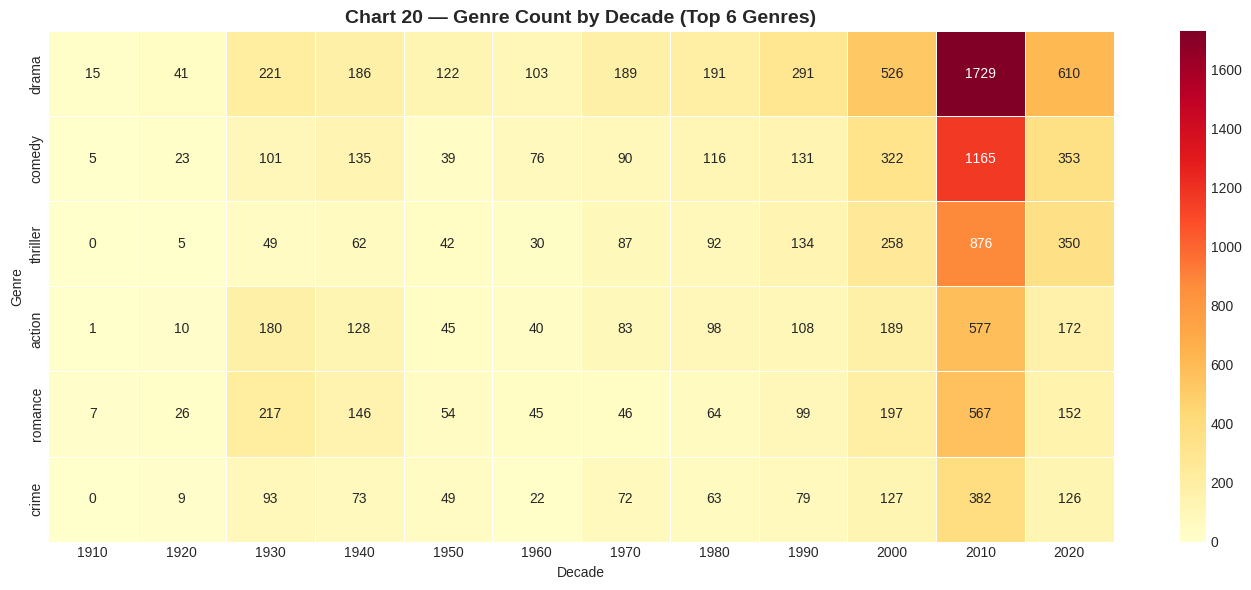

In [93]:
# Top 6 genres only for clean heatmap
top6_genres = pd.Series(all_genres).value_counts().head(6).index.tolist()

# Build genre-decade matrix
genre_decade_data = {}
for genre in top6_genres:
    genre_movies_filt = movies[movies['genres'].str.contains(genre, na=False)]
    genre_decade_data[genre] = genre_movies_filt.groupby('decade').size()

genre_decade_df = pd.DataFrame(genre_decade_data).fillna(0).T

plt.figure(figsize=(14, 6))
sns.heatmap(genre_decade_df, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Chart 20 — Genre Count by Decade (Top 6 Genres)',
          fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('chart20_genre_decade_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap with genre and decade axes shows how genre popularity has evolved over time — true multivariate analysis.

##### 2. What is/are the insight(s) found from the chart?

Drama and Comedy grew massively in 2010s and 2020s.
Thriller content also spiked recently.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on EDA findings, here are key suggestions for the platform:

1. Quality Filter — Only surface movies with IMDb ≥ 6.0 in recommendations to maintain quality.
2. Genre Sections — Create dedicated Drama and Comedy homepage sections — these dominate the platform.
3. Classics Section — Old movies (pre-1970) have higher avg ratings — feature in 'Classics' section.
4. Critics Choice — High IMDb but low popularity movies are hidden gems — feature them prominently.
5. Expand International Content — US dominates production; adding more India/Korea/Europe content
   helps attract global subscribers.
6. Balanced Scoring — Combine IMDb score + normalized TMDB popularity for fair recommendation
   ranking — neither popularity alone nor rating alone is sufficient.
7. Invest in Shows — Shows have slightly higher avg IMDb than movies — original show production
   can improve platform rating and drive binge-watching subscriptions.

# **Conclusion**

This EDA project successfully analyzed the Netflix Titles dataset and uncovered
20 key insights across Univariate, Bivariate, and Multivariate analysis.

Key Findings:
- Most movies score 5–7 on IMDb — near-normal distribution, slight left skew.
- Drama is the most common and consistently above-average rated genre.
- TMDB popularity has weak correlation (+0.08) with IMDb — popular ≠ quality.
- Older movies (pre-1970) have higher average ratings — classics are undervalued.
- Content production grew exponentially after 2000 — recent decade dominates volume.
- IMDb and TMDB scores are strongly correlated (+0.72) — both measure quality similarly.
- US dominates content production — platform needs international content diversity.
- Shows have slightly higher avg ratings than movies — original shows are valuable investment.
- 1,021 missing imdb_scores — median imputation prevents bias in quality analysis.
- Popularity normalization is critical — a few viral movies have extreme outlier scores.